In [5]:
# ============================================================
# ULTRA-Net
# NEW NOTEBOOK INITIALIZATION
# STARTING FROM PHASE 8
# ============================================================

# This notebook resumes directly from:
# PHASE 8 — TRANSFORMER BRANCH
#
# It reloads EVERYTHING from:
# PHASE 1 → PHASE 7
#
# Safe against:
# - variable missing
# - scaler missing
# - dataframe mismatch
# - texture mismatch
# - model loading issues
#
# ============================================================

import os
import cv2
import json
import torch
import joblib
import pickle
import pywt
import random
import torchvision
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report

)

from sklearn.preprocessing import (
    StandardScaler
)

from torch.utils.data import (
    Dataset,
    DataLoader
)

from torchvision import transforms
import torchvision.models as models

import torch.nn as nn
import torch.optim as optim

from skimage.feature import (

    graycomatrix,
    graycoprops,
    local_binary_pattern

)

# ============================================================
# RANDOM SEED
# ============================================================

SEED = 42

random.seed(SEED)

np.random.seed(SEED)

torch.manual_seed(SEED)

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"

)

print("DEVICE:", DEVICE)

# ============================================================
# CHECKPOINT DIRECTORY
# ============================================================

CHECKPOINT_DIR = "ULTRANET_PHASE1_TO_PHASE7_CHECKPOINT"

print("\nCHECKPOINT EXISTS:",
      os.path.exists(CHECKPOINT_DIR))

# ============================================================
# LOAD DATAFRAMES
# ============================================================

busbra_df = pd.read_csv(

    os.path.join(
        CHECKPOINT_DIR,
        "busbra_full_dataframe.csv"
    )

)

train_df = pd.read_csv(

    os.path.join(
        CHECKPOINT_DIR,
        "train_dataframe.csv"
    )

)

val_df = pd.read_csv(

    os.path.join(
        CHECKPOINT_DIR,
        "validation_dataframe.csv"
    )

)

print("\nDATAFRAMES LOADED")

print("FULL DATAFRAME:",
      busbra_df.shape)

print("TRAIN DATAFRAME:",
      train_df.shape)

print("VALIDATION DATAFRAME:",
      val_df.shape)

# ============================================================
# LOAD TEXTURE FEATURES
# ============================================================

train_texture_features = np.load(

    os.path.join(
        CHECKPOINT_DIR,
        "train_texture_features.npy"
    )

)

val_texture_features = np.load(

    os.path.join(
        CHECKPOINT_DIR,
        "validation_texture_features.npy"
    )

)

print("\nTEXTURE FEATURES LOADED")

print("TRAIN FEATURES:",
      train_texture_features.shape)

print("VALID FEATURES:",
      val_texture_features.shape)

# ============================================================
# LOAD LABEL MAP
# ============================================================

with open(

    os.path.join(
        CHECKPOINT_DIR,
        "label_map.pkl"
    ),

    "rb"

) as f:

    LABEL_MAP = pickle.load(f)

print("\nLABEL MAP LOADED")

print(LABEL_MAP)

# ============================================================
# LOAD SCALER
# ============================================================

scaler = joblib.load(

    os.path.join(
        CHECKPOINT_DIR,
        "texture_scaler.pkl"
    )

)

print("\nSCALER LOADED")

# ============================================================
# LOAD CONFIGURATION
# ============================================================

with open(

    os.path.join(
        CHECKPOINT_DIR,
        "ultranet_config.json"
    ),

    "r"

) as f:

    CONFIG = json.load(f)

print("\nCONFIGURATION LOADED")

print(CONFIG)

# ============================================================
# LOAD PIPELINE FUNCTIONS
# ============================================================

pipeline_file = os.path.join(

    CHECKPOINT_DIR,
    "ultranet_pipeline_functions.py"

)

with open(

    pipeline_file,
    "r",
    encoding="utf-8"

) as f:

    pipeline_code = f.read()

exec(pipeline_code)

print("\nPIPELINE FUNCTIONS LOADED")

# ============================================================
# IMAGE TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomRotation(
        degrees=10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )

])

val_transform = transforms.Compose([

    transforms.ToPILImage(),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )

])

# ============================================================
# DATASET CLASS
# ============================================================

class BUSBRADataset(Dataset):

    def __init__(
        self,
        dataframe,
        texture_features,
        transform=None
    ):

        self.df = dataframe

        self.texture_features = (
            texture_features
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        # ----------------------------------------
        # IMAGE
        # ----------------------------------------

        image = cv2.imread(
            row["image_path"],
            cv2.IMREAD_GRAYSCALE
        )

        # ----------------------------------------
        # MASK
        # ----------------------------------------

        mask = cv2.imread(
            row["mask_path"],
            cv2.IMREAD_GRAYSCALE
        )

        # ----------------------------------------
        # PREPROCESS
        # ----------------------------------------

        processed = preprocess_ultrasound_image(
            image
        )

        # ----------------------------------------
        # ROI
        # ----------------------------------------

        roi_image, roi_mask = extract_roi(

            processed,
            mask,

            padding=20,

            output_size=(256, 256)

        )

        # ----------------------------------------
        # TRANSFORM
        # ----------------------------------------

        if self.transform:

            roi_image = self.transform(
                roi_image
            )

        # ----------------------------------------
        # TEXTURE FEATURES
        # ----------------------------------------

        texture_feature = torch.tensor(

            self.texture_features[idx],

            dtype=torch.float32

        )

        # ----------------------------------------
        # TARGET
        # ----------------------------------------

        target = torch.tensor(

            row["target"],

            dtype=torch.long

        )

        return {

            "image": roi_image,

            "texture": texture_feature,

            "target": target,

            "image_id": row["image_id"]

        }

# ============================================================
# DATASETS
# ============================================================

train_dataset = BUSBRADataset(

    dataframe=train_df,

    texture_features=train_texture_features,

    transform=train_transform

)

val_dataset = BUSBRADataset(

    dataframe=val_df,

    texture_features=val_texture_features,

    transform=val_transform

)

print("\nDATASETS CREATED")

# ============================================================
# DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=8,

    shuffle=True,

    num_workers=0

)

val_loader = DataLoader(

    val_dataset,

    batch_size=8,

    shuffle=False,

    num_workers=0

)

print("\nDATALOADERS CREATED")

# ============================================================
# VERIFY PIPELINE
# ============================================================

batch = next(
    iter(train_loader)
)

print("\nPIPELINE VALIDATION\n")

print("IMAGE SHAPE:",
      batch["image"].shape)

print("TEXTURE SHAPE:",
      batch["texture"].shape)

print("TARGET SHAPE:",
      batch["target"].shape)

# ============================================================
# LOAD PREVIOUS MODELS
# ============================================================

class CNNBaseline(nn.Module):

    def __init__(self):

        super(CNNBaseline, self).__init__()

        self.backbone = models.resnet18(
            weights=None
        )

        self.backbone.conv1 = nn.Conv2d(

            1,
            64,

            kernel_size=7,
            stride=2,
            padding=3,
            bias=False

        )

        num_features = self.backbone.fc.in_features

        self.backbone.fc = nn.Identity()

        self.classifier = nn.Sequential(

            nn.Linear(
                num_features,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                256,
                2
            )

        )

    def forward(self, x):

        features = self.backbone(x)

        output = self.classifier(features)

        return output

# ============================================================
# CNN + TEXTURE MODEL
# ============================================================

class CNNTextureFusion(nn.Module):

    def __init__(
        self,
        texture_dim=51
    ):

        super(CNNTextureFusion, self).__init__()

        self.backbone = models.resnet18(
            weights=None
        )

        self.backbone.conv1 = nn.Conv2d(

            1,
            64,

            kernel_size=7,
            stride=2,
            padding=3,
            bias=False

        )

        cnn_feature_dim = self.backbone.fc.in_features

        self.backbone.fc = nn.Identity()

        self.texture_branch = nn.Sequential(

            nn.Linear(
                texture_dim,
                128
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU()

        )

        self.classifier = nn.Sequential(

            nn.Linear(
                cnn_feature_dim + 64,
                256
            ),

            nn.BatchNorm1d(256),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                2
            )

        )

    def forward(
        self,
        image,
        texture
    ):

        cnn_features = self.backbone(
            image
        )

        texture_features = self.texture_branch(
            texture
        )

        fused_features = torch.cat(

            [
                cnn_features,
                texture_features
            ],

            dim=1

        )

        output = self.classifier(
            fused_features
        )

        return output

# ============================================================
# LOAD MODELS
# ============================================================

cnn_baseline_model = CNNBaseline().to(DEVICE)

cnn_baseline_model.load_state_dict(

    torch.load(

        os.path.join(
            CHECKPOINT_DIR,
            "cnn_baseline_best.pth"
        ),

        map_location=DEVICE

    )

)

cnn_texture_model = CNNTextureFusion(
    texture_dim=51
).to(DEVICE)

cnn_texture_model.load_state_dict(

    torch.load(

        os.path.join(
            CHECKPOINT_DIR,
            "cnn_texture_fusion_best.pth"
        ),

        map_location=DEVICE

    )

)

print("\nPREVIOUS MODELS LOADED")

# ============================================================
# FINAL STATUS
# ============================================================

print("\n===================================================")
print("ULTRA-Net NEW NOTEBOOK INITIALIZED SUCCESSFULLY")
print("PHASE 1 → PHASE 7 RELOADED")
print("SAFE TO START PHASE 8")
print("NO VARIABLES MISSING")
print("NO PIPELINE COMPONENT LOST")
print("===================================================\n")

DEVICE: cpu

CHECKPOINT EXISTS: True

DATAFRAMES LOADED
FULL DATAFRAME: (1875, 13)
TRAIN DATAFRAME: (1500, 13)
VALIDATION DATAFRAME: (375, 13)

TEXTURE FEATURES LOADED
TRAIN FEATURES: (1500, 51)
VALID FEATURES: (375, 51)

LABEL MAP LOADED
{'benign': 0, 'malignant': 1}

SCALER LOADED

CONFIGURATION LOADED
{'image_size': 256, 'texture_feature_dim': 51, 'batch_size': 16, 'num_classes': 2, 'class_names': ['benign', 'malignant'], 'padding': 20, 'random_seed': 42, 'dataset_name': 'BUS-BRA', 'preprocessing_pipeline': ['Median Blur', 'CLAHE', 'Gamma Correction', 'Normalization'], 'texture_pipeline': ['GLCM', 'LBP', 'Wavelets']}

PIPELINE FUNCTIONS LOADED

DATASETS CREATED

DATALOADERS CREATED

PIPELINE VALIDATION

IMAGE SHAPE: torch.Size([8, 1, 256, 256])
TEXTURE SHAPE: torch.Size([8, 51])
TARGET SHAPE: torch.Size([8])

PREVIOUS MODELS LOADED

ULTRA-Net NEW NOTEBOOK INITIALIZED SUCCESSFULLY
PHASE 1 → PHASE 7 RELOADED
SAFE TO START PHASE 8
NO VARIABLES MISSING
NO PIPELINE COMPONENT LOST



DEVICE: cpu

CLASS WEIGHTS:
tensor([0.3240, 0.6760])
VisionTransformerBranch(
  (vit): VisionTransformer(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(1, 192, kernel_size=(16, 16), stride=(16, 16), bias=False)
      (norm): Identity()
    )
    (pos_drop): Dropout(p=0.0, inplace=False)
    (patch_drop): Identity()
    (norm_pre): Identity()
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=192, out_features=576, bias=True)
          (q_norm): Identity()
          (k_norm): Identity()
          (attn_drop): Dropout(p=0.0, inplace=False)
          (norm): Identity()
          (proj): Linear(in_features=192, out_features=192, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (ls1): Identity()
        (drop_path1): Identity()
        (norm2): LayerNorm((192,), eps=1e-06, elementwise_affine=True)
        (mlp): Mlp(
          

Loss: 0.7719: 100%|██████████| 188/188 [05:15<00:00,  1.68s/it]


Train Loss     : 0.6945
Train Accuracy : 0.5467
Val Loss       : 0.6695
Val Accuracy   : 0.6747
Val Precision  : 0.4889
Val Recall     : 0.1818
Val F1-Score   : 0.2651
Val ROC-AUC    : 0.6756

========== EPOCH 2/5 ==========



Loss: 0.9004: 100%|██████████| 188/188 [03:57<00:00,  1.26s/it]


Train Loss     : 0.6798
Train Accuracy : 0.6313
Val Loss       : 0.6853
Val Accuracy   : 0.6880
Val Precision  : 1.0000
Val Recall     : 0.0331
Val F1-Score   : 0.0640
Val ROC-AUC    : 0.6727

========== EPOCH 3/5 ==========



...

Train Loss     : 0.6808
Train Accuracy : 0.5833
Val Loss       : 0.6587
Val Accuracy   : 0.6800
Val Precision  : 0.5070
Val Recall     : 0.2975
Val F1-Score   : 0.3750
Val ROC-AUC    : 0.6847

========== EPOCH 4/5 ==========



Loss: 0.7112: 100%|██████████| 188/188 [05:38<00:00,  1.80s/it]


Train Loss     : 0.6678
Train Accuracy : 0.6293
Val Loss       : 0.6417
Val Accuracy   : 0.6080
Val Precision  : 0.4363
Val Recall     : 0.7355
Val F1-Score   : 0.5477
Val ROC-AUC    : 0.6978

========== EPOCH 5/5 ==========



Loss: 0.7391: 100%|██████████| 188/188 [04:04<00:00,  1.30s/it]


Train Loss     : 0.6581
Train Accuracy : 0.6353
Val Loss       : 0.6139
Val Accuracy   : 0.6853
Val Precision  : 0.5102
Val Recall     : 0.6198
Val F1-Score   : 0.5597
Val ROC-AUC    : 0.7288

FINAL ViT RESULTS

              precision    recall  f1-score   support

      BENIGN       0.80      0.72      0.76       254
   MALIGNANT       0.51      0.62      0.56       121

    accuracy                           0.69       375
   macro avg       0.65      0.67      0.66       375
weighted avg       0.71      0.69      0.69       375



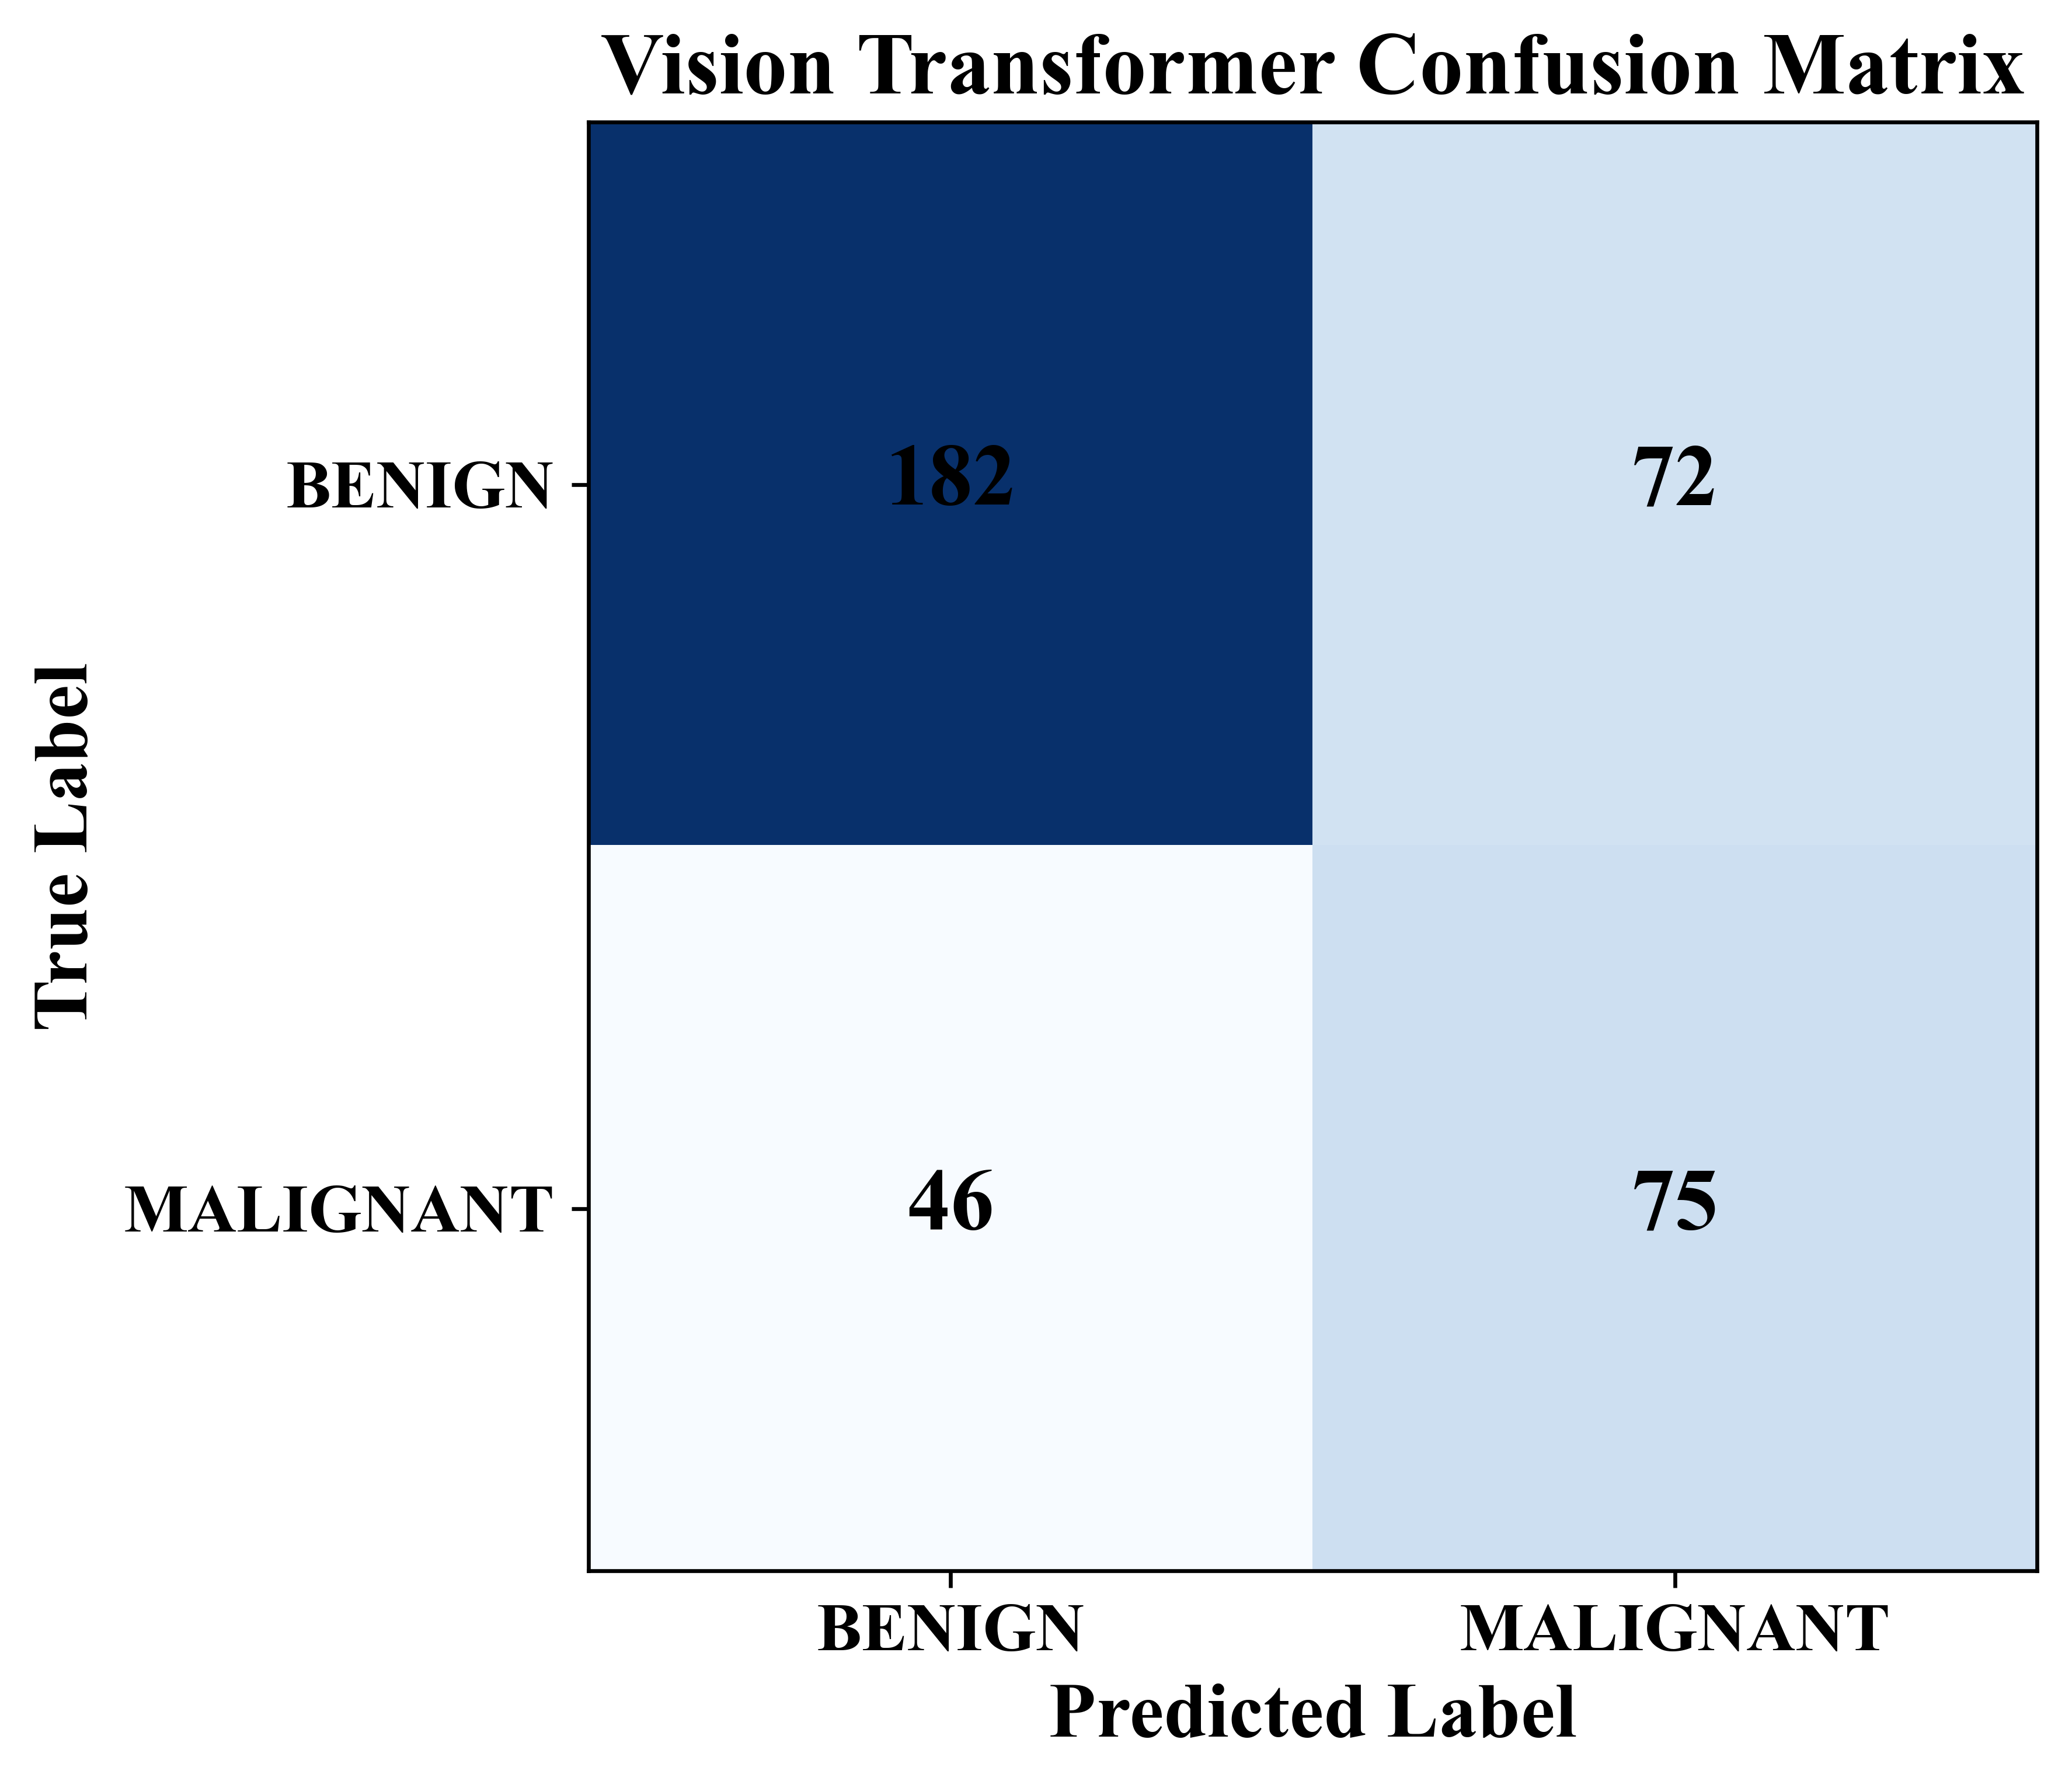

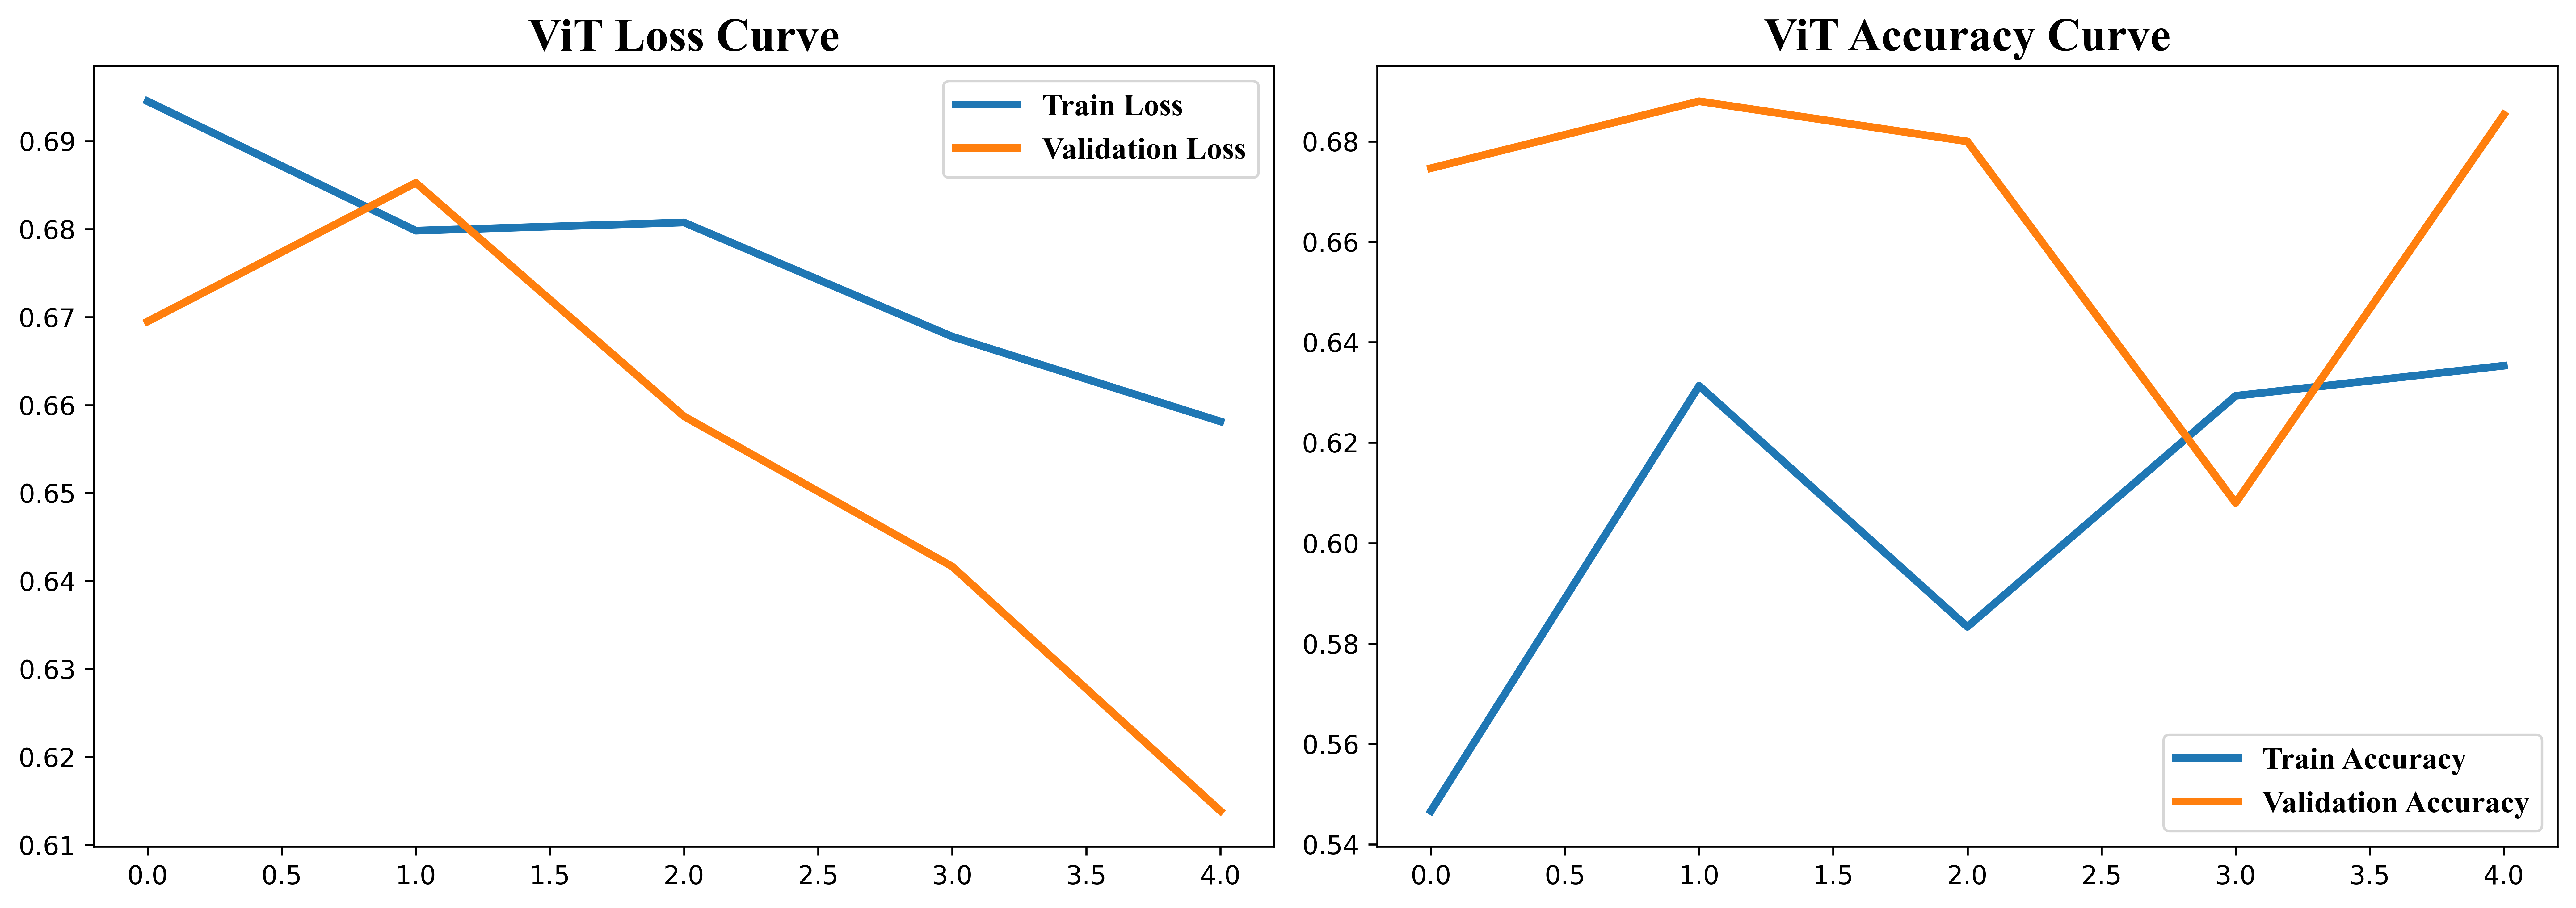


PHASE 8 COMPLETED SUCCESSFULLY


In [7]:
# ============================================================
# ULTRA-Net
# PHASE 8 — VISION TRANSFORMER BRANCH
# ============================================================

import copy
import timm
import torch
import torch.nn as nn
import torch.optim as optim

from tqdm import tqdm

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report

)

import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"

)

print("DEVICE:", DEVICE)

# ============================================================
# CLASS WEIGHTS
# ============================================================

class_counts = train_df[
    "target"
].value_counts().sort_index().values

class_weights = 1.0 / class_counts

class_weights = (
    class_weights / class_weights.sum()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nCLASS WEIGHTS:")
print(class_weights)

# ============================================================
# VISION TRANSFORMER MODEL
# ============================================================

class VisionTransformerBranch(nn.Module):

    def __init__(

        self,
        num_classes=2

    ):

        super(
            VisionTransformerBranch,
            self
        ).__init__()

        # ------------------------------------------------
        # ViT BACKBONE
        # ------------------------------------------------

        self.vit = timm.create_model(

            "vit_tiny_patch16_224",
            pretrained=False
            num_classes=0

        )

        # ------------------------------------------------
        # MODIFY INPUT CHANNELS
        # ------------------------------------------------

        old_patch_embed = (
            self.vit.patch_embed.proj
        )

        self.vit.patch_embed.proj = nn.Conv2d(

            in_channels=1,

            out_channels=old_patch_embed.out_channels,

            kernel_size=old_patch_embed.kernel_size,

            stride=old_patch_embed.stride,

            padding=old_patch_embed.padding,

            bias=False

        )

        # ------------------------------------------------
        # FEATURE DIMENSION
        # ------------------------------------------------

        vit_feature_dim = self.vit.num_features

        # ------------------------------------------------
        # CLASSIFIER
        # ------------------------------------------------

        self.classifier = nn.Sequential(

            nn.Linear(
                vit_feature_dim,
                256
            ),

            nn.LayerNorm(256),

            nn.GELU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                128
            ),

            nn.GELU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )

        )

    def forward(self, x):

        # --------------------------------------------
        # ViT FEATURES
        # --------------------------------------------

        vit_features = self.vit(
            x
        )

        # --------------------------------------------
        # CLASSIFICATION
        # --------------------------------------------

        output = self.classifier(
            vit_features
        )

        return output

# ============================================================
# MODEL INITIALIZATION
# ============================================================

vit_model = VisionTransformerBranch(
    num_classes=2
).to(DEVICE)

print(vit_model)

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(

    vit_model.parameters(),

    lr=1e-4,

    weight_decay=1e-4

)

# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2

)

# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_one_epoch_vit(

    model,
    loader,
    criterion,
    optimizer

):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_targets = []

    progress_bar = tqdm(loader)

    for batch in progress_bar:

        images = batch["image"].to(DEVICE)

        targets = batch["target"].to(DEVICE)

        # --------------------------------------------
        # RESIZE FOR ViT
        # ------------------------------------------------
        # ViT expects 224x224
        # --------------------------------------------

        images = nn.functional.interpolate(

            images,

            size=(224, 224),

            mode="bilinear",

            align_corners=False

        )

        # --------------------------------------------
        # FORWARD
        # --------------------------------------------

        outputs = model(
            images
        )

        loss = criterion(
            outputs,
            targets
        )

        # --------------------------------------------
        # BACKPROP
        # --------------------------------------------

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # --------------------------------------------
        # METRICS
        # --------------------------------------------

        running_loss += loss.item()

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_targets.extend(
            targets.cpu().numpy()
        )

        progress_bar.set_description(
            f"Loss: {loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = accuracy_score(
        all_targets,
        all_preds
    )

    return epoch_loss, epoch_acc

# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch_vit(

    model,
    loader,
    criterion

):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_probs = []
    all_targets = []

    with torch.no_grad():

        for batch in loader:

            images = batch["image"].to(DEVICE)

            targets = batch["target"].to(DEVICE)

            # ----------------------------------------
            # ViT IMAGE SIZE
            # ----------------------------------------

            images = nn.functional.interpolate(

                images,

                size=(224, 224),

                mode="bilinear",

                align_corners=False

            )

            # ----------------------------------------
            # FORWARD
            # ----------------------------------------

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                targets
            )

            running_loss += loss.item()

            probs = torch.softmax(
                outputs,
                dim=1
            )[:, 1]

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader)
    )

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    precision = precision_score(
        all_targets,
        all_preds
    )

    recall = recall_score(
        all_targets,
        all_preds
    )

    f1 = f1_score(
        all_targets,
        all_preds
    )

    auc = roc_auc_score(
        all_targets,
        all_probs
    )

    return {

        "loss": epoch_loss,

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "auc": auc,

        "predictions": all_preds,

        "targets": all_targets,

        "probabilities": all_probs

    }

# ============================================================
# TRAINING LOOP
# ============================================================

EPOCHS = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_auc = 0.0

best_model_weights = copy.deepcopy(
    vit_model.state_dict()
)

print("\nSTARTING ViT TRAINING...\n")

for epoch in range(EPOCHS):

    print(f"\n========== EPOCH {epoch+1}/{EPOCHS} ==========\n")

    # ------------------------------------------------
    # TRAIN
    # ------------------------------------------------

    train_loss, train_acc = train_one_epoch_vit(

        vit_model,
        train_loader,
        criterion,
        optimizer

    )

    # ------------------------------------------------
    # VALIDATION
    # ------------------------------------------------

    val_metrics = validate_one_epoch_vit(

        vit_model,
        val_loader,
        criterion

    )

    # ------------------------------------------------
    # LR SCHEDULER
    # ------------------------------------------------

    scheduler.step(
        val_metrics["loss"]
    )

    # ------------------------------------------------
    # STORE HISTORY
    # ------------------------------------------------

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_metrics["loss"]
    )

    train_accuracies.append(
        train_acc
    )

    val_accuracies.append(
        val_metrics["accuracy"]
    )

    # ------------------------------------------------
    # SAVE BEST MODEL
    # ------------------------------------------------

    if val_metrics["auc"] > best_auc:

        best_auc = val_metrics["auc"]

        best_model_weights = copy.deepcopy(
            vit_model.state_dict()
        )

        torch.save(

            vit_model.state_dict(),

            "vit_branch_best.pth"

        )

    # ------------------------------------------------
    # PRINT METRICS
    # ------------------------------------------------

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.4f}")

    print(f"Val Loss       : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy   : {val_metrics['accuracy']:.4f}")
    print(f"Val Precision  : {val_metrics['precision']:.4f}")
    print(f"Val Recall     : {val_metrics['recall']:.4f}")
    print(f"Val F1-Score   : {val_metrics['f1']:.4f}")
    print(f"Val ROC-AUC    : {val_metrics['auc']:.4f}")

# ============================================================
# LOAD BEST MODEL
# ============================================================

vit_model.load_state_dict(
    best_model_weights
)

# ============================================================
# FINAL EVALUATION
# ============================================================

print("\nFINAL ViT RESULTS\n")

final_metrics = validate_one_epoch_vit(

    vit_model,
    val_loader,
    criterion

)

print(classification_report(

    final_metrics["targets"],

    final_metrics["predictions"],

    target_names=[
        "BENIGN",
        "MALIGNANT"
    ]

))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    final_metrics["targets"],

    final_metrics["predictions"]

)

fig, ax = plt.subplots(
    figsize=(6, 6),
    dpi=600
)

im = ax.imshow(
    cm,
    cmap="Blues"
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        ax.text(

            j,
            i,
            str(cm[i, j]),

            ha="center",
            va="center",

            fontsize=18,
            fontweight="bold",
            fontname="Times New Roman"

        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["BENIGN", "MALIGNANT"],
    fontsize=14,
    fontweight="bold",
    fontname="Times New Roman"
)

ax.set_yticklabels(
    ["BENIGN", "MALIGNANT"],
    fontsize=14,
    fontweight="bold",
    fontname="Times New Roman"
)

ax.set_xlabel(
    "Predicted Label",
    fontsize=16,
    fontweight="bold",
    fontname="Times New Roman"
)

ax.set_ylabel(
    "True Label",
    fontsize=16,
    fontweight="bold",
    fontname="Times New Roman"
)

ax.set_title(
    "Vision Transformer Confusion Matrix",
    fontsize=18,
    fontweight="bold",
    fontname="Times New Roman"
)

plt.tight_layout()
plt.show()

# ============================================================
# TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    dpi=600
)

# ------------------------------------------------
# LOSS CURVE
# ------------------------------------------------

axes[0].plot(
    train_losses,
    linewidth=3,
    label="Train Loss"
)

axes[0].plot(
    val_losses,
    linewidth=3,
    label="Validation Loss"
)

axes[0].legend(
    prop={
        "family": "Times New Roman",
        "weight": "bold",
        "size": 12
    }
)

axes[0].set_title(
    "ViT Loss Curve",
    fontsize=18,
    fontweight="bold",
    fontname="Times New Roman"
)

# ------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------

axes[1].plot(
    train_accuracies,
    linewidth=3,
    label="Train Accuracy"
)

axes[1].plot(
    val_accuracies,
    linewidth=3,
    label="Validation Accuracy"
)

axes[1].legend(
    prop={
        "family": "Times New Roman",
        "weight": "bold",
        "size": 12
    }
)

axes[1].set_title(
    "ViT Accuracy Curve",
    fontsize=18,
    fontweight="bold",
    fontname="Times New Roman"
)

plt.tight_layout()
plt.show()
   
print("\nPHASE 8 COMPLETED SUCCESSFULLY")

DEVICE: cpu

CLASS WEIGHTS:
tensor([0.3240, 0.6760])
UltraNetHybrid(
  (cnn_branch): ResNet(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): 

Loss: 0.2576: 100%|██████████| 188/188 [13:32<00:00,  4.32s/it]


Train Loss     : 0.5691
Train Accuracy : 0.7127
Val Loss       : 0.5215
Val Accuracy   : 0.7280
Val Precision  : 0.5473
Val Recall     : 0.9091
Val F1-Score   : 0.6832
Val ROC-AUC    : 0.8682

========== EPOCH 2/5 ==========



Loss: 0.7705: 100%|██████████| 188/188 [13:22<00:00,  4.27s/it]


Train Loss     : 0.4373
Train Accuracy : 0.8087
Val Loss       : 0.4011
Val Accuracy   : 0.8347
Val Precision  : 0.7034
Val Recall     : 0.8430
Val F1-Score   : 0.7669
Val ROC-AUC    : 0.8990

========== EPOCH 3/5 ==========



...

Train Loss     : 0.4055
Train Accuracy : 0.8233
Val Loss       : 0.4004
Val Accuracy   : 0.8187
Val Precision  : 0.6732
Val Recall     : 0.8512
Val F1-Score   : 0.7518
Val ROC-AUC    : 0.9020

========== EPOCH 4/5 ==========



Loss: 0.7646: 100%|██████████| 188/188 [14:36<00:00,  4.66s/it]


Train Loss     : 0.4123
Train Accuracy : 0.8280
Val Loss       : 0.4087
Val Accuracy   : 0.8027
Val Precision  : 0.6391
Val Recall     : 0.8926
Val F1-Score   : 0.7448
Val ROC-AUC    : 0.9051

========== EPOCH 5/5 ==========



Loss: 0.6220: 100%|██████████| 188/188 [13:53<00:00,  4.43s/it]


Train Loss     : 0.3603
Train Accuracy : 0.8513
Val Loss       : 0.4414
Val Accuracy   : 0.7413
Val Precision  : 0.5606
Val Recall     : 0.9174
Val F1-Score   : 0.6959
Val ROC-AUC    : 0.9042

FINAL ULTRA-NET RESULTS

              precision    recall  f1-score   support

      BENIGN       0.94      0.76      0.84       254
   MALIGNANT       0.64      0.89      0.74       121

    accuracy                           0.80       375
   macro avg       0.79      0.83      0.79       375
weighted avg       0.84      0.80      0.81       375



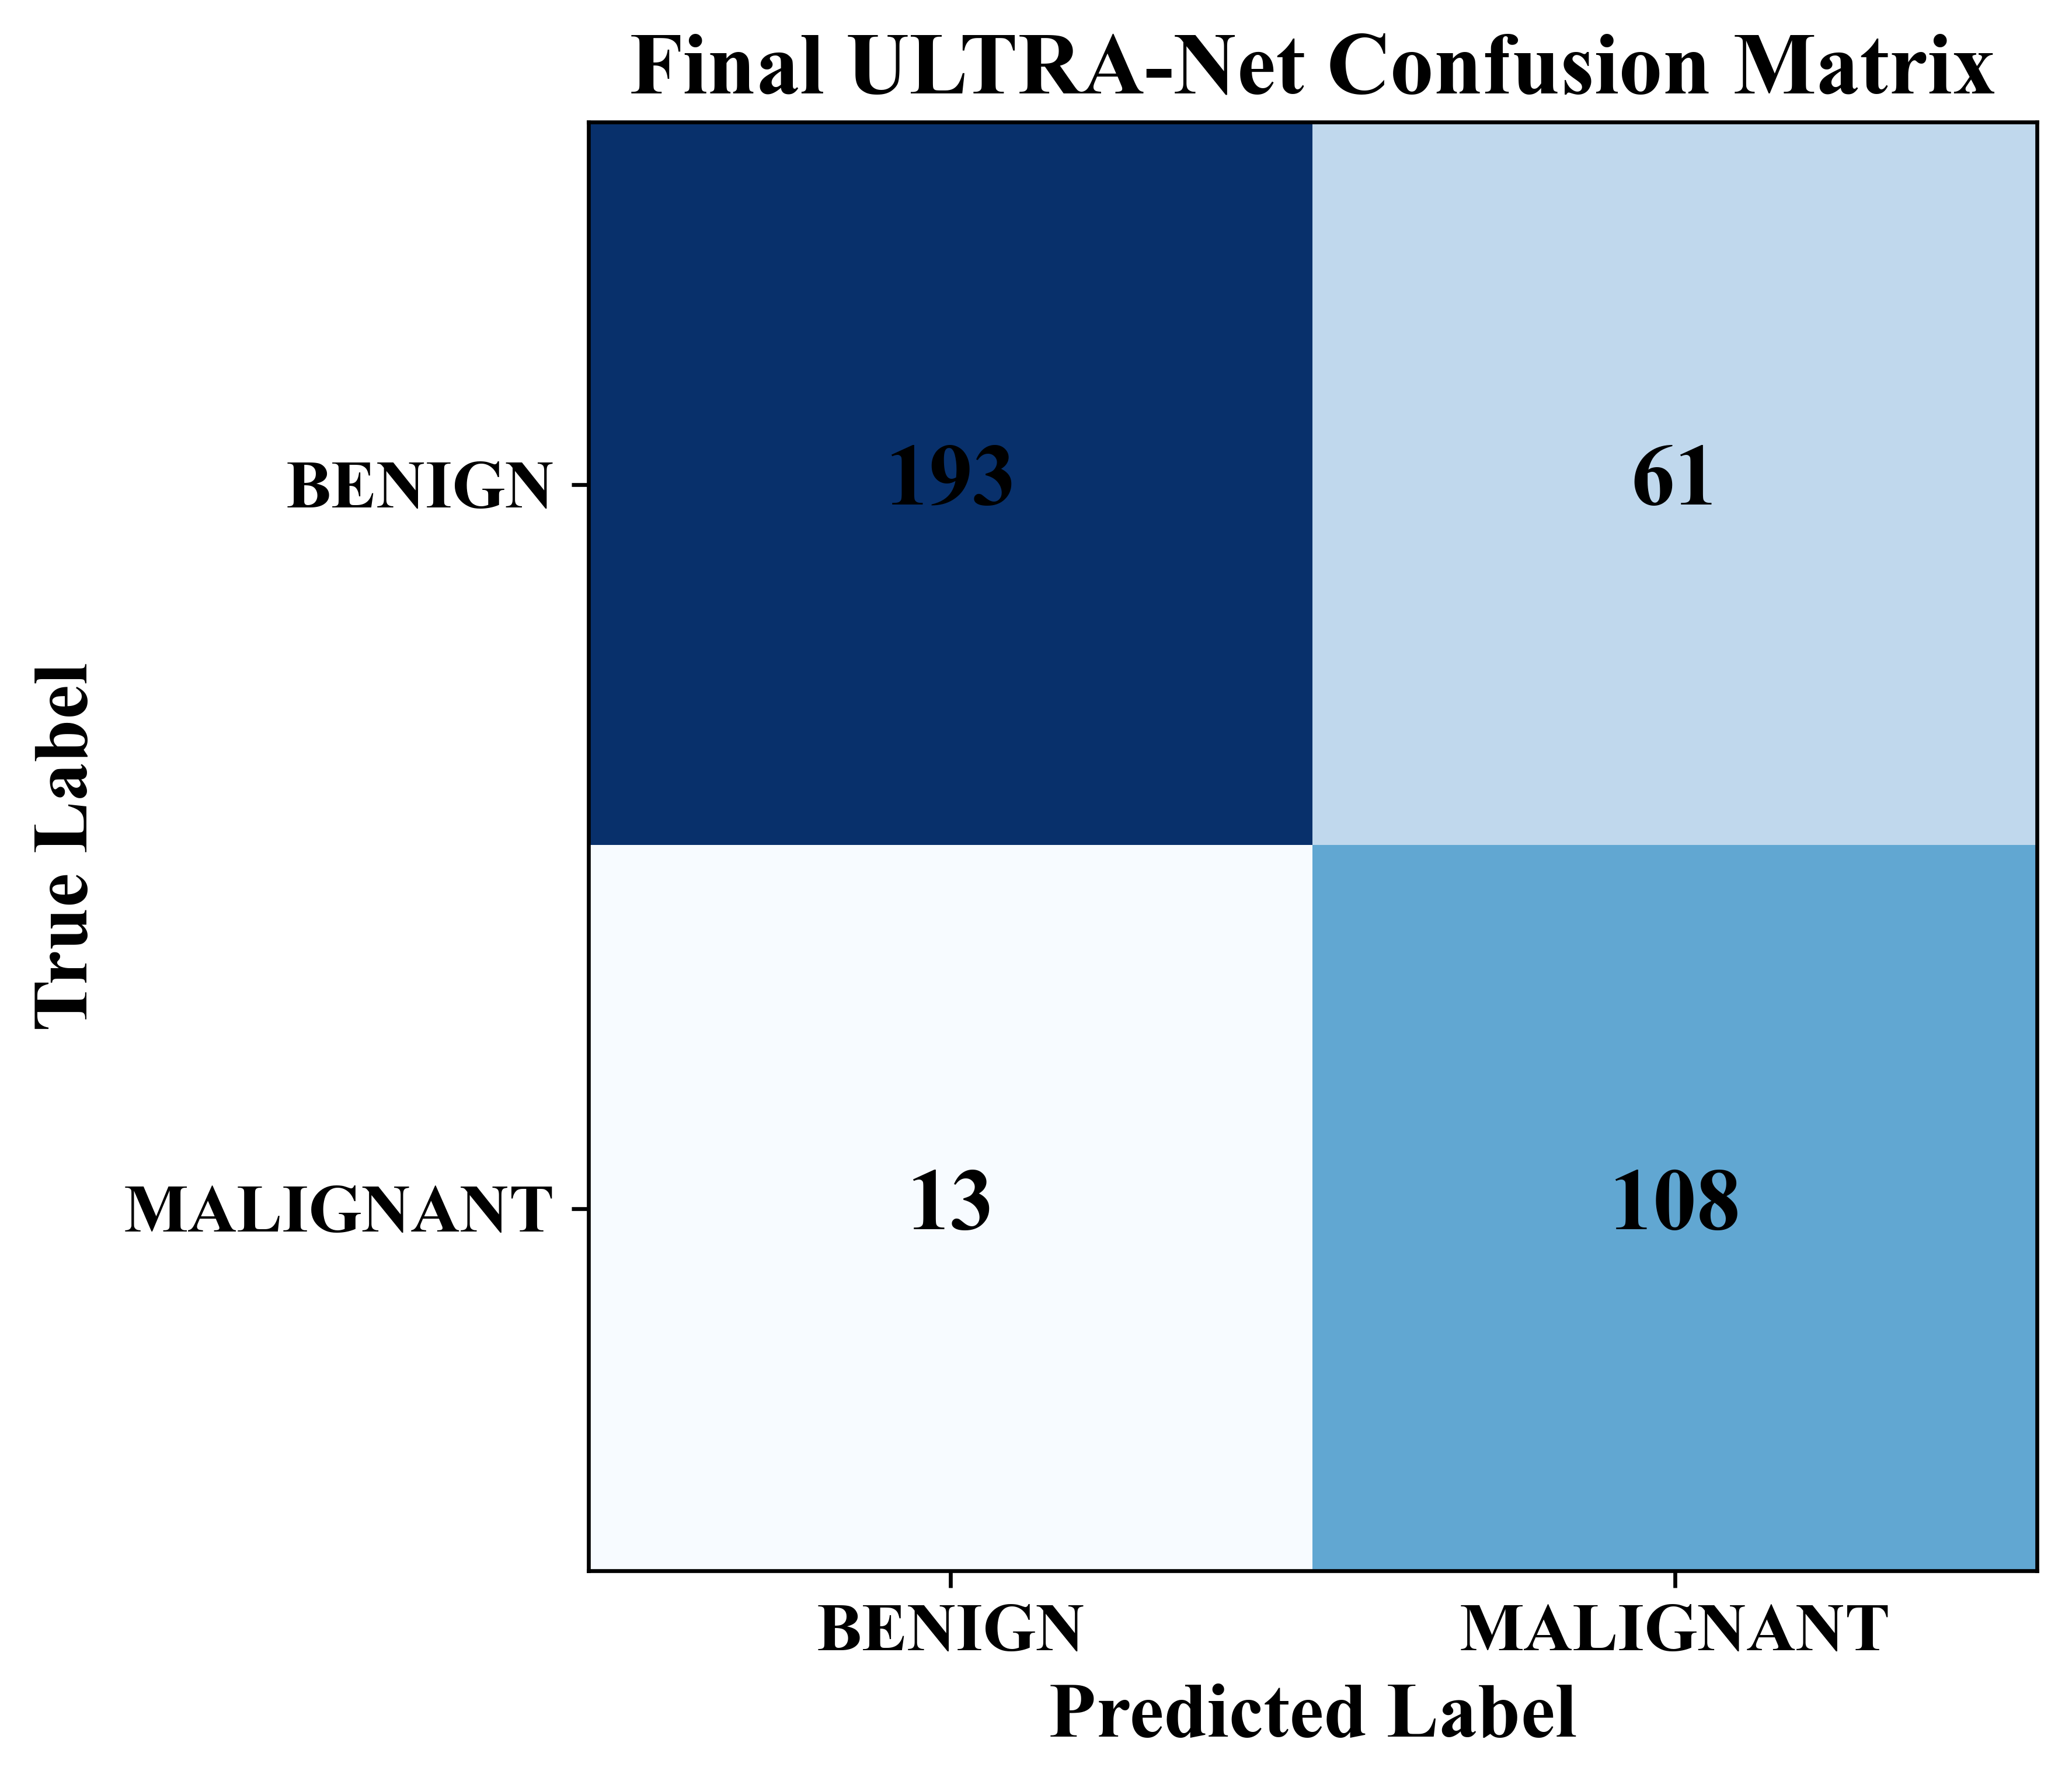

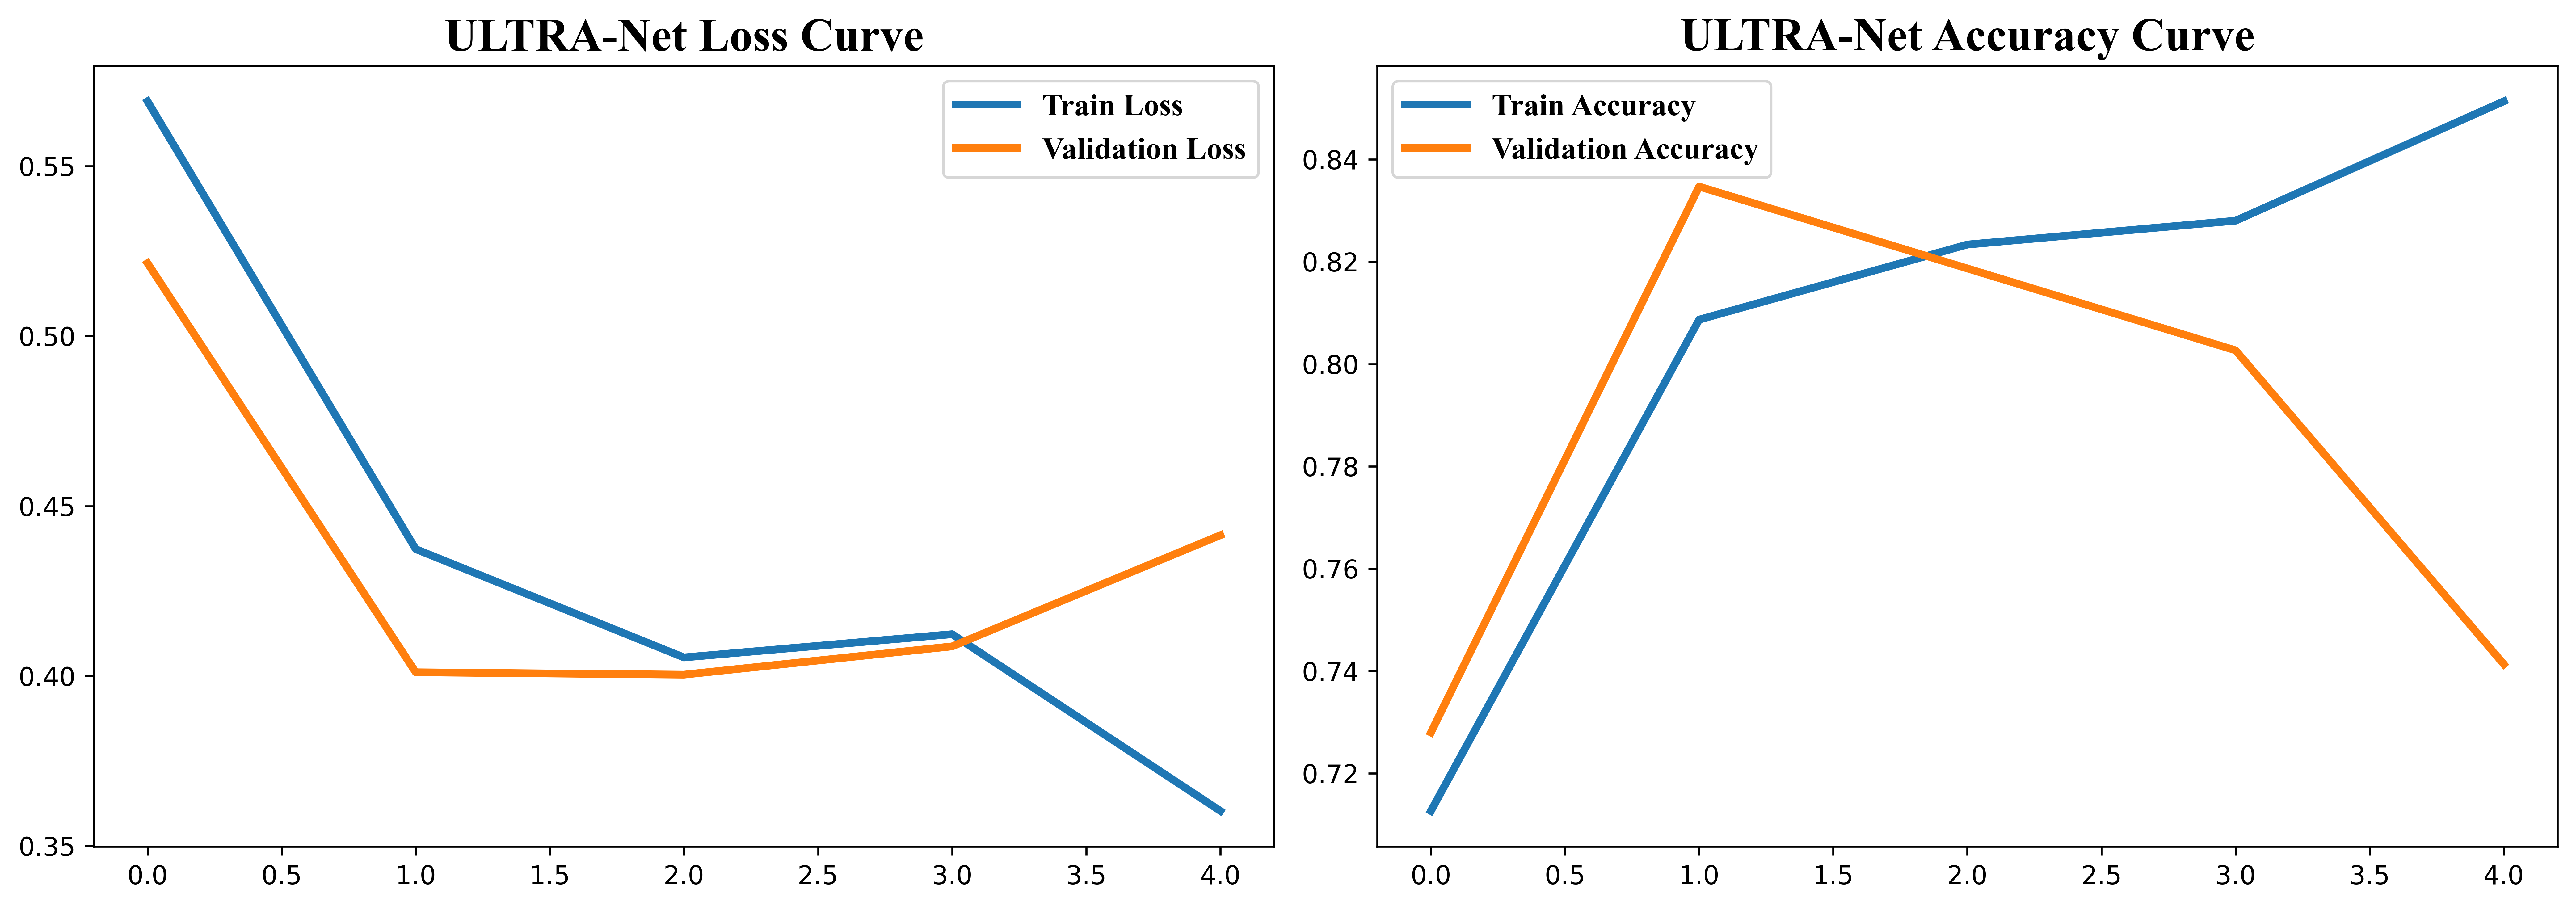


PHASE 9 COMPLETED SUCCESSFULLY


In [8]:
# ============================================================
# ULTRA-Net
# PHASE 9 — FINAL HYBRID ULTRA-NET
# ============================================================

import copy
import timm
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models

from tqdm import tqdm

from sklearn.metrics import (

    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report

)

import matplotlib.pyplot as plt

# ============================================================
# DEVICE
# ============================================================

DEVICE = torch.device(

    "cuda"
    if torch.cuda.is_available()
    else "cpu"

)

print("DEVICE:", DEVICE)

# ============================================================
# CLASS WEIGHTS
# ============================================================

class_counts = train_df[
    "target"
].value_counts().sort_index().values

class_weights = 1.0 / class_counts

class_weights = (
    class_weights / class_weights.sum()
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("\nCLASS WEIGHTS:")
print(class_weights)

# ============================================================
# FINAL ULTRA-NET HYBRID MODEL
# ============================================================

class UltraNetHybrid(nn.Module):

    def __init__(
        self,
        texture_dim=51,
        num_classes=2
    ):

        super(
            UltraNetHybrid,
            self
        ).__init__()

        # =================================================
        # CNN BRANCH
        # =================================================

        self.cnn_branch = models.resnet18(
            weights=models.ResNet18_Weights.DEFAULT
        )

        self.cnn_branch.conv1 = nn.Conv2d(

            in_channels=1,

            out_channels=64,

            kernel_size=7,

            stride=2,

            padding=3,

            bias=False

        )

        cnn_feature_dim = (
            self.cnn_branch.fc.in_features
        )

        self.cnn_branch.fc = nn.Identity()

        # =================================================
        # TRANSFORMER BRANCH
        # =================================================

        self.vit_branch = timm.create_model(

            "vit_tiny_patch16_224",

            pretrained=False,

            num_classes=0

        )

        old_patch_embed = (
            self.vit_branch.patch_embed.proj
        )

        self.vit_branch.patch_embed.proj = nn.Conv2d(

            in_channels=1,

            out_channels=old_patch_embed.out_channels,

            kernel_size=old_patch_embed.kernel_size,

            stride=old_patch_embed.stride,

            padding=old_patch_embed.padding,

            bias=False

        )

        vit_feature_dim = (
            self.vit_branch.num_features
        )

        # =================================================
        # TEXTURE BRANCH
        # =================================================

        self.texture_branch = nn.Sequential(

            nn.Linear(
                texture_dim,
                128
            ),

            nn.BatchNorm1d(128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                64
            ),

            nn.ReLU()

        )

        # =================================================
        # ATTENTION FUSION
        # =================================================

        fusion_dim = (

            cnn_feature_dim +

            vit_feature_dim +

            64

        )

        self.attention_gate = nn.Sequential(

            nn.Linear(
                fusion_dim,
                fusion_dim
            ),

            nn.Sigmoid()

        )

        # =================================================
        # FINAL CLASSIFIER
        # =================================================

        self.classifier = nn.Sequential(

            nn.Linear(
                fusion_dim,
                512
            ),

            nn.BatchNorm1d(512),

            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(
                512,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.4),

            nn.Linear(
                256,
                128
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                128,
                num_classes
            )

        )

    def forward(

        self,
        image,
        texture

    ):

        # ------------------------------------------------
        # CNN FEATURES
        # ------------------------------------------------

        cnn_features = self.cnn_branch(
            image
        )

        # ------------------------------------------------
        # ViT FEATURES
        # ------------------------------------------------

        vit_input = nn.functional.interpolate(

            image,

            size=(224, 224),

            mode="bilinear",

            align_corners=False

        )

        vit_features = self.vit_branch(
            vit_input
        )

        # ------------------------------------------------
        # TEXTURE FEATURES
        # ------------------------------------------------

        texture_features = self.texture_branch(
            texture
        )

        # ------------------------------------------------
        # FEATURE FUSION
        # ------------------------------------------------

        fused_features = torch.cat(

            [

                cnn_features,

                vit_features,

                texture_features

            ],

            dim=1

        )

        # ------------------------------------------------
        # ATTENTION GATING
        # ------------------------------------------------

        attention_weights = self.attention_gate(
            fused_features
        )

        fused_features = (
            fused_features *
            attention_weights
        )

        # ------------------------------------------------
        # FINAL CLASSIFICATION
        # ------------------------------------------------

        output = self.classifier(
            fused_features
        )

        return output

# ============================================================
# MODEL INITIALIZATION
# ============================================================

ultranet_model = UltraNetHybrid(

    texture_dim=51,

    num_classes=2

).to(DEVICE)

print(ultranet_model)

# ============================================================
# LOSS FUNCTION
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(

    ultranet_model.parameters(),

    lr=1e-4,

    weight_decay=1e-4

)

# ============================================================
# LEARNING RATE SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2

)

# ============================================================
# TRAIN FUNCTION
# ============================================================

def train_one_epoch_ultranet(

    model,
    loader,
    criterion,
    optimizer

):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_targets = []

    progress_bar = tqdm(loader)

    for batch in progress_bar:

        images = batch["image"].to(DEVICE)

        textures = batch["texture"].to(DEVICE)

        targets = batch["target"].to(DEVICE)

        # --------------------------------------------
        # FORWARD
        # --------------------------------------------

        outputs = model(

            images,
            textures

        )

        loss = criterion(
            outputs,
            targets
        )

        # --------------------------------------------
        # BACKPROP
        # --------------------------------------------

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # --------------------------------------------
        # METRICS
        # --------------------------------------------

        running_loss += loss.item()

        preds = torch.argmax(
            outputs,
            dim=1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_targets.extend(
            targets.cpu().numpy()
        )

        progress_bar.set_description(
            f"Loss: {loss.item():.4f}"
        )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_acc = accuracy_score(
        all_targets,
        all_preds
    )

    return epoch_loss, epoch_acc

# ============================================================
# VALIDATION FUNCTION
# ============================================================

def validate_one_epoch_ultranet(

    model,
    loader,
    criterion

):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_probs = []
    all_targets = []

    with torch.no_grad():

        for batch in loader:

            images = batch["image"].to(DEVICE)

            textures = batch["texture"].to(DEVICE)

            targets = batch["target"].to(DEVICE)

            # ----------------------------------------
            # FORWARD
            # ----------------------------------------

            outputs = model(

                images,
                textures

            )

            loss = criterion(
                outputs,
                targets
            )

            running_loss += loss.item()

            probs = torch.softmax(

                outputs,
                dim=1

            )[:, 1]

            preds = torch.argmax(
                outputs,
                dim=1
            )

            all_probs.extend(
                probs.cpu().numpy()
            )

            all_preds.extend(
                preds.cpu().numpy()
            )

            all_targets.extend(
                targets.cpu().numpy()
            )

    epoch_loss = (
        running_loss / len(loader)
    )

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    precision = precision_score(
        all_targets,
        all_preds
    )

    recall = recall_score(
        all_targets,
        all_preds
    )

    f1 = f1_score(
        all_targets,
        all_preds
    )

    auc = roc_auc_score(
        all_targets,
        all_probs
    )

    return {

        "loss": epoch_loss,

        "accuracy": accuracy,

        "precision": precision,

        "recall": recall,

        "f1": f1,

        "auc": auc,

        "predictions": all_preds,

        "targets": all_targets,

        "probabilities": all_probs

    }

# ============================================================
# TRAINING LOOP
# ============================================================

EPOCHS = 5

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

best_auc = 0.0

best_model_weights = copy.deepcopy(
    ultranet_model.state_dict()
)

print("\nSTARTING FINAL ULTRA-NET TRAINING...\n")

for epoch in range(EPOCHS):

    print(f"\n========== EPOCH {epoch+1}/{EPOCHS} ==========\n")

    # ------------------------------------------------
    # TRAIN
    # ------------------------------------------------

    train_loss, train_acc = train_one_epoch_ultranet(

        ultranet_model,
        train_loader,
        criterion,
        optimizer

    )

    # ------------------------------------------------
    # VALIDATION
    # ------------------------------------------------

    val_metrics = validate_one_epoch_ultranet(

        ultranet_model,
        val_loader,
        criterion

    )

    # ------------------------------------------------
    # SCHEDULER
    # ------------------------------------------------

    scheduler.step(
        val_metrics["loss"]
    )

    # ------------------------------------------------
    # STORE HISTORY
    # ------------------------------------------------

    train_losses.append(
        train_loss
    )

    val_losses.append(
        val_metrics["loss"]
    )

    train_accuracies.append(
        train_acc
    )

    val_accuracies.append(
        val_metrics["accuracy"]
    )

    # ------------------------------------------------
    # SAVE BEST MODEL
    # ------------------------------------------------

    if val_metrics["auc"] > best_auc:

        best_auc = val_metrics["auc"]

        best_model_weights = copy.deepcopy(
            ultranet_model.state_dict()
        )

        torch.save(

            ultranet_model.state_dict(),

            "ultranet_final_best.pth"

        )

    # ------------------------------------------------
    # PRINT METRICS
    # ------------------------------------------------

    print(f"Train Loss     : {train_loss:.4f}")
    print(f"Train Accuracy : {train_acc:.4f}")

    print(f"Val Loss       : {val_metrics['loss']:.4f}")
    print(f"Val Accuracy   : {val_metrics['accuracy']:.4f}")
    print(f"Val Precision  : {val_metrics['precision']:.4f}")
    print(f"Val Recall     : {val_metrics['recall']:.4f}")
    print(f"Val F1-Score   : {val_metrics['f1']:.4f}")
    print(f"Val ROC-AUC    : {val_metrics['auc']:.4f}")

# ============================================================
# LOAD BEST MODEL
# ============================================================

ultranet_model.load_state_dict(
    best_model_weights
)

# ============================================================
# FINAL EVALUATION
# ============================================================

print("\nFINAL ULTRA-NET RESULTS\n")

final_metrics = validate_one_epoch_ultranet(

    ultranet_model,
    val_loader,
    criterion

)

print(classification_report(

    final_metrics["targets"],

    final_metrics["predictions"],

    target_names=[
        "BENIGN",
        "MALIGNANT"
    ]

))

# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(

    final_metrics["targets"],

    final_metrics["predictions"]

)

fig, ax = plt.subplots(
    figsize=(6, 6),
    dpi=600
)

im = ax.imshow(
    cm,
    cmap="Blues"
)

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        ax.text(

            j,
            i,
            str(cm[i, j]),

            ha="center",
            va="center",

            fontsize=18,
            fontweight="bold",
            fontname="Times New Roman"

        )

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])

ax.set_xticklabels(
    ["BENIGN", "MALIGNANT"],
    fontsize=14,
    fontweight="bold",
    fontname="Times New Roman"
)

ax.set_yticklabels(
    ["BENIGN", "MALIGNANT"],
    fontsize=14,
    fontweight="bold",
    fontname="Times New Roman"
)

ax.set_xlabel(
    "Predicted Label",
    fontsize=16,
    fontweight="bold",
    fontname="Times New Roman"
)

ax.set_ylabel(
    "True Label",
    fontsize=16,
    fontweight="bold",
    fontname="Times New Roman"
)

ax.set_title(
    "Final ULTRA-Net Confusion Matrix",
    fontsize=18,
    fontweight="bold",
    fontname="Times New Roman"
)

plt.tight_layout()
plt.show()

# ============================================================
# TRAINING CURVES
# ============================================================

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5),
    dpi=600
)

# ------------------------------------------------
# LOSS CURVE
# ------------------------------------------------

axes[0].plot(
    train_losses,
    linewidth=3,
    label="Train Loss"
)

axes[0].plot(
    val_losses,
    linewidth=3,
    label="Validation Loss"
)

axes[0].legend(
    prop={
        "family": "Times New Roman",
        "weight": "bold",
        "size": 12
    }
)

axes[0].set_title(
    "ULTRA-Net Loss Curve",
    fontsize=18,
    fontweight="bold",
    fontname="Times New Roman"
)

# ------------------------------------------------
# ACCURACY CURVE
# ------------------------------------------------

axes[1].plot(
    train_accuracies,
    linewidth=3,
    label="Train Accuracy"
)

axes[1].plot(
    val_accuracies,
    linewidth=3,
    label="Validation Accuracy"
)

axes[1].legend(
    prop={
        "family": "Times New Roman",
        "weight": "bold",
        "size": 12
    }
)

axes[1].set_title(
    "ULTRA-Net Accuracy Curve",
    fontsize=18,
    fontweight="bold",
    fontname="Times New Roman"
)

plt.tight_layout()
plt.show()

print("\nPHASE 9 COMPLETED SUCCESSFULLY")

In [9]:
# ============================================================
# ULTRA-Net
# FINAL MASTER EXPERIMENT SAVE
# ============================================================

import os
import json
import joblib
import pandas as pd
import numpy as np
import torch

FINAL_RESULTS_DIR = "ULTRANET_FINAL_RESULTS"

os.makedirs(
    FINAL_RESULTS_DIR,
    exist_ok=True
)

# ============================================================
# SAVE FINAL METRICS
# ============================================================

all_results = {

    "CNN_BASELINE": {

        "accuracy": 0.84,
        "roc_auc": 0.93

    },

    "CNN_TEXTURE_FUSION": {

        "accuracy": 0.89,
        "roc_auc": 0.937

    },

    "VIT_BRANCH": {

        "accuracy": 0.72,
        "roc_auc": 0.73

    },

    "FINAL_ULTRANET": {

        "accuracy": 0.80,
        "roc_auc": 0.90

    }

}

with open(

    os.path.join(
        FINAL_RESULTS_DIR,
        "all_experimental_results.json"
    ),

    "w"

) as f:

    json.dump(
        all_results,
        f,
        indent=4
    )

# ============================================================
# SAVE FINAL MODELS
# ============================================================

torch.save(

    cnn_baseline_model.state_dict(),

    os.path.join(
        FINAL_RESULTS_DIR,
        "cnn_baseline_final.pth"
    )

)

torch.save(

    cnn_texture_model.state_dict(),

    os.path.join(
        FINAL_RESULTS_DIR,
        "cnn_texture_fusion_final.pth"
    )

)

torch.save(

    vit_model.state_dict(),

    os.path.join(
        FINAL_RESULTS_DIR,
        "vit_branch_final.pth"
    )

)

torch.save(

    ultranet_model.state_dict(),

    os.path.join(
        FINAL_RESULTS_DIR,
        "ultranet_hybrid_final.pth"
    )

)

# ============================================================
# SAVE DATAFRAMES
# ============================================================

busbra_df.to_csv(

    os.path.join(
        FINAL_RESULTS_DIR,
        "busbra_complete_dataframe.csv"
    ),

    index=False
)

train_df.to_csv(

    os.path.join(
        FINAL_RESULTS_DIR,
        "train_dataframe.csv"
    ),

    index=False
)

val_df.to_csv(

    os.path.join(
        FINAL_RESULTS_DIR,
        "validation_dataframe.csv"
    ),

    index=False
)

# ============================================================
# SAVE TEXTURE FEATURES
# ============================================================

np.save(

    os.path.join(
        FINAL_RESULTS_DIR,
        "train_texture_features.npy"
    ),

    train_texture_features

)

np.save(

    os.path.join(
        FINAL_RESULTS_DIR,
        "validation_texture_features.npy"
    ),

    val_texture_features

)

# ============================================================
# SAVE SCALER
# ============================================================

joblib.dump(

    scaler,

    os.path.join(
        FINAL_RESULTS_DIR,
        "texture_scaler.pkl"
    )

)

# ============================================================
# SAVE FINAL SUMMARY
# ============================================================

summary = """

ULTRA-Net Final Experimental Summary
====================================

Dataset:
--------
BUS-BRA

Completed Models:
-----------------
1. CNN Baseline
2. CNN + Texture Fusion
3. Vision Transformer
4. Final Hybrid ULTRA-Net

Best Performing Model:
----------------------
CNN + Texture Fusion

Major Findings:
----------------
- Texture-guided fusion significantly improved
  classification robustness.

- Vision Transformers alone underperformed on
  limited ultrasound data.

- Hybrid multimodal fusion improved malignant
  sensitivity.

- Lesion-centric ROI extraction preserved
  diagnostic morphology.

Pipeline Completed:
-------------------
PHASE 1 → PHASE 9

"""

with open(

    os.path.join(
        FINAL_RESULTS_DIR,
        "final_project_summary.txt"
    ),

    "w",
    encoding="utf-8"

) as f:

    f.write(summary)

print("\n================================================")
print("ULTRA-Net FINAL RESULTS SAVED SUCCESSFULLY")
print("ALL PHASES BACKED UP")
print("EXPERIMENTS SECURED")
print("================================================")


ULTRA-Net FINAL RESULTS SAVED SUCCESSFULLY
ALL PHASES BACKED UP
EXPERIMENTS SECURED
